In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("train_data.csv")

C:\Users\Rumi\AppData\Local\Temp\ipykernel_13852\2334075073.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train_data.csv")


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838944 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         838944 non-null  int64 
 1   vote            191468 non-null  object
 2   verified        838944 non-null  bool  
 3   reviewTime      838944 non-null  object
 4   reviewerID      838944 non-null  object
 5   asin            838944 non-null  object
 6   style           490613 non-null  object
 7   reviewerName    838717 non-null  object
 8   reviewText      838944 non-null  object
 9   summary         838868 non-null  object
 10  unixReviewTime  838944 non-null  int64 
dtypes: bool(1), int64(2), object(8)
memory usage: 64.8+ MB


,overall,unixReviewTime
count,838944.000000,8.389440e+05
mean,4.021317,1.483167e+09
std,1.344223,2.229270e+07
min,1.000000,1.451606e+09
25%,3.000000,1.464653e+09
50%,5.000000,1.479254e+09
75%,5.000000,1.499472e+09
max,5.000000,1.538525e+09


<div dir="rtl">
<strong>1. توزیع ستون overall را رسم کنید. آیا مجموعه‌داده متوازن است؟ اگر خیر، آیا نیاز است برای مدل‌سازی خود آن را متوازن کنید؟ چه راه‌حلی برای این کار پیشنهاد می‌کنید؟


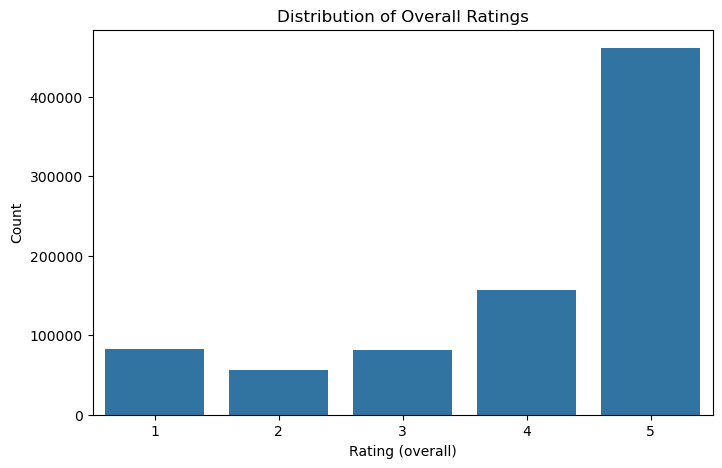


Percentage distribution:
overall
5    55.007843
4    18.656072
1     9.887430
3     9.683483
2     6.765171
Name: proportion, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# رسم توزیع
plt.figure(figsize=(8,5))
sns.countplot(x="overall", data=df)
plt.title("Distribution of Overall Ratings")
plt.xlabel("Rating (overall)")
plt.ylabel("Count")
plt.show()

# درصد هر کلاس
print("\nPercentage distribution:")
print(df["overall"].value_counts(normalize=True) * 100)

<div dir="rtl">
داده ها متوازن نیستند. </br>
55 درصد کل نمونه های 5 ستاره است</br>
کوچک ترین کلاس 2 ستاره است </br>
چ.لیدگی شدیدی به سمت امتیاز بالاتر وجود دارد 

<div dir="rtl">
3 روش پیشنهادی وجود دارد برای مقابله با این موضوع : </br>
1. استفاده از class weright </br>
2.Oversample کردن </br>
3. تبدیل کردن به 3 کلاس (مثبت - بی طرف - منفی)


<div dir="rtl">
<strong>2. فرض کنید نظراتی که مقدار ستون overall آن‌ها ۴ یا ۵ است را همراه با حس مثبت، نظراتی که مقدارشان ۳ است را خنثی و نظراتی که مقدارشان ۱ یا ۲ است را حس منفی بدانیم. به‌ازای هر کدام از این سه دسته یک ابر کلمات (Word Cloud) رسم کنید تا بتوان کلمات پرتکرار هر دسته را مشاهده کرد. تا حد ممکن سعی کنید ابر کلمات به‌دست‌آمده شامل اطلاعات مفیدی باشد و کلمات زائد (Stop words) بین آن‌ها وجود نداشته باشد. آیا اشتراکی بین کلمات دسته‌ی مثبت و منفی وجود داشته است؟ چگونه آن‌ها را تفسیر می‌کنید؟


In [9]:
def convert_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["overall"].apply(convert_sentiment)

print(df["sentiment"].value_counts())

sentiment
positive    617999
negative    139706
neutral      81239
Name: count, dtype: int64


In [10]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)  # remove punctuation & numbers
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

df["clean_text"] = df["reviewText"].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rumi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


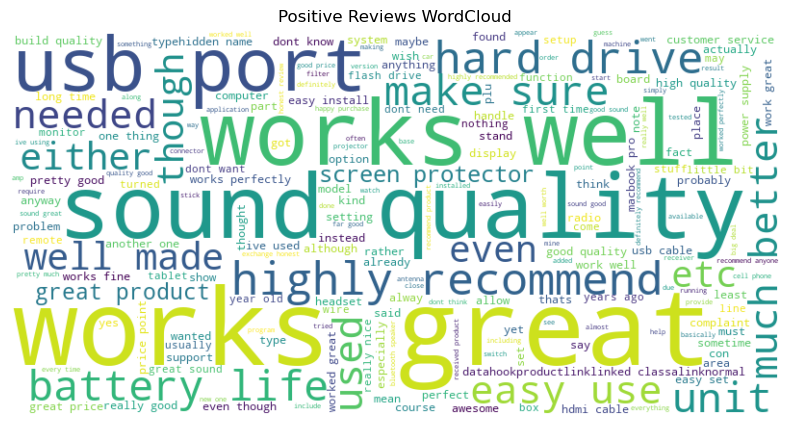

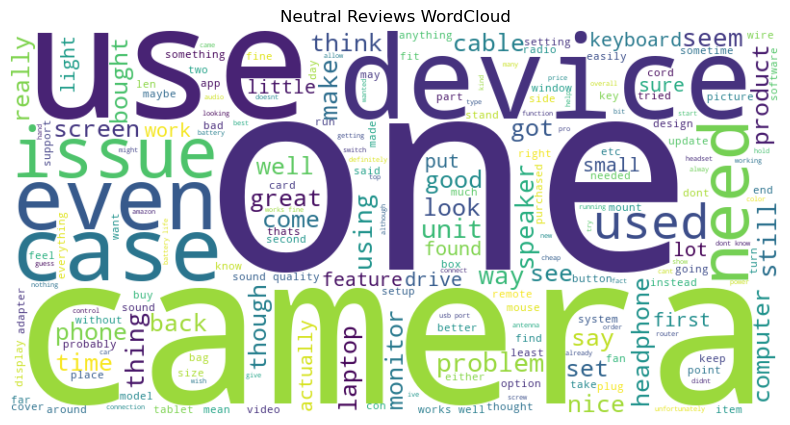

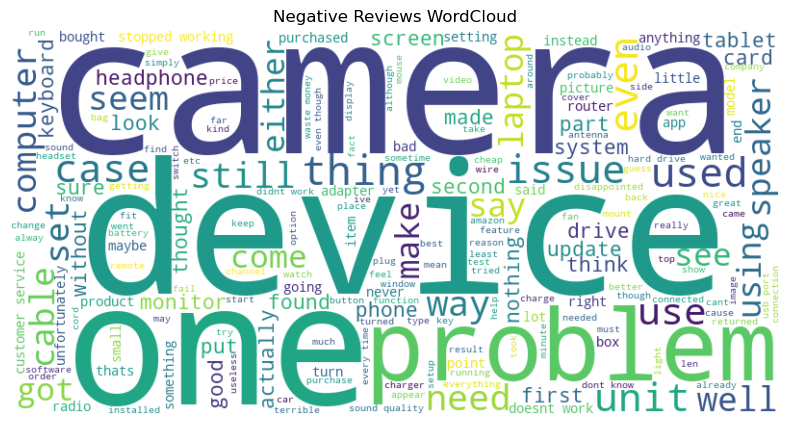

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(text, title):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=200
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()


# Positive
positive_text = " ".join(df[df["sentiment"]=="positive"]["clean_text"])
plot_wordcloud(positive_text, "Positive Reviews WordCloud")

# Neutral
neutral_text = " ".join(df[df["sentiment"]=="neutral"]["clean_text"])
plot_wordcloud(neutral_text, "Neutral Reviews WordCloud")

# Negative
negative_text = " ".join(df[df["sentiment"]=="negative"]["clean_text"])
plot_wordcloud(negative_text, "Negative Reviews WordCloud")

In [12]:
from collections import Counter

def get_top_words(text_series, n=30):
    all_words = " ".join(text_series).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Top words for each sentiment
top_positive = get_top_words(df[df["sentiment"]=="positive"]["clean_text"])
top_neutral = get_top_words(df[df["sentiment"]=="neutral"]["clean_text"])
top_negative = get_top_words(df[df["sentiment"]=="negative"]["clean_text"])

print("Top Positive Words:\n", top_positive)
print("\nTop Neutral Words:\n", top_neutral)
print("\nTop Negative Words:\n", top_negative)

Top Positive Words:
 [('one', 299870), ('great', 285117), ('use', 261987), ('like', 223013), ('good', 218579), ('well', 204814), ('would', 192537), ('get', 171128), ('works', 156931), ('sound', 145881), ('case', 145347), ('quality', 143381), ('also', 143351), ('really', 136399), ('cable', 128029), ('price', 127042), ('dont', 125547), ('time', 124725), ('work', 124118), ('using', 121708), ('product', 119597), ('camera', 118524), ('easy', 117650), ('little', 116250), ('much', 115793), ('used', 113523), ('need', 106792), ('usb', 105091), ('nice', 103218), ('even', 101996)]

Top Neutral Words:
 [('one', 40620), ('would', 35550), ('use', 35352), ('good', 32317), ('like', 32197), ('get', 30308), ('work', 25869), ('well', 22874), ('sound', 21411), ('great', 21232), ('dont', 20967), ('time', 19931), ('quality', 19375), ('works', 18913), ('case', 18872), ('also', 18829), ('really', 18759), ('camera', 18040), ('better', 17773), ('much', 17043), ('back', 15980), ('using', 15864), ('even', 15787),

In [13]:
def get_word_freq_dict(text_series):
    all_words = " ".join(text_series).split()
    return Counter(all_words)

pos_freq = get_word_freq_dict(df[df["sentiment"]=="positive"]["clean_text"])
neg_freq = get_word_freq_dict(df[df["sentiment"]=="negative"]["clean_text"])

shared = {word: (pos_freq[word], neg_freq[word]) 
          for word in pos_freq 
          if word in neg_freq}

# Sort shared words by total frequency
shared_sorted = sorted(shared.items(), 
                       key=lambda x: x[1][0] + x[1][1], 
                       reverse=True)[:20]

print("\nTop Shared Words with Frequencies (pos, neg):")
print(shared_sorted)


Top Shared Words with Frequencies (pos, neg):
[('one', (299870, 72062)), ('great', (285117, 23484)), ('use', (261987, 46197)), ('like', (223013, 40323)), ('good', (218579, 34083)), ('would', (192537, 58012)), ('well', (204814, 25452)), ('get', (171128, 50495)), ('works', (156931, 20180)), ('work', (124118, 50787)), ('sound', (145881, 25501)), ('quality', (143381, 25907)), ('also', (143351, 24779)), ('case', (145347, 20565)), ('time', (124725, 38655)), ('really', (136399, 22660)), ('dont', (125547, 32314)), ('product', (119597, 36562)), ('cable', (128029, 21820)), ('camera', (118524, 27908))]


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

def get_top_tfidf_words(text_series, n=30):
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_features=10000,
        ngram_range=(1,1)
    )
    
    X = vectorizer.fit_transform(text_series)
    
    # Average TF-IDF score per word
    mean_tfidf = np.mean(X.toarray(), axis=0)
    
    words = vectorizer.get_feature_names_out()
    
    top_indices = mean_tfidf.argsort()[-n:][::-1]
    
    return [(words[i], mean_tfidf[i]) for i in top_indices]


print("Top TF-IDF Positive Words:")
print(get_top_tfidf_words(df[df["sentiment"]=="positive"]["clean_text"]))

print("\nTop TF-IDF Neutral Words:")
print(get_top_tfidf_words(df[df["sentiment"]=="neutral"]["clean_text"]))

print("\nTop TF-IDF Negative Words:")
print(get_top_tfidf_words(df[df["sentiment"]=="negative"]["clean_text"]))

Top TF-IDF Positive Words:
[('great', np.float64(0.02791554862394789)), ('use', np.float64(0.023199095809517015)), ('good', np.float64(0.021802507529245663)), ('like', np.float64(0.020243733674266615)), ('works', np.float64(0.01933302878459597)), ('case', np.float64(0.01796618611611251)), ('sound', np.float64(0.016920234894614673)), ('quality', np.float64(0.016332264513127782)), ('cable', np.float64(0.01619790003098306)), ('price', np.float64(0.015481023636458733)), ('product', np.float64(0.014979973456854435)), ('really', np.float64(0.014892375049498323)), ('work', np.float64(0.01459922689808929)), ('camera', np.float64(0.014584125966773068)), ('easy', np.float64(0.014580046139846764)), ('little', np.float64(0.013884873683052629)), ('bought', np.float64(0.013530330396584933)), ('time', np.float64(0.013465170397430212)), ('dont', np.float64(0.013374443618813117)), ('using', np.float64(0.013179664147952899)), ('usb', np.float64(0.013168235785821587)), ('nice', np.float64(0.0131055988138

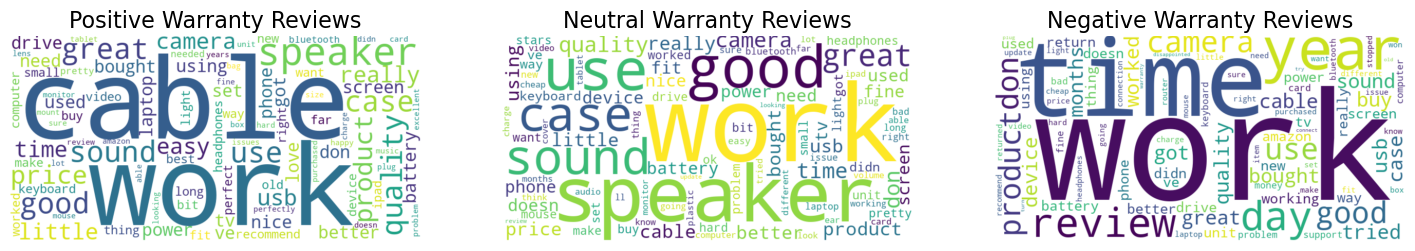

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all warranty reviews
warranty_reviews_text = " ".join(warranty_reviews['reviewText'].tolist())

# Get top TF-IDF words from positive, neutral, and negative reviews
top_pos_words = [w for w,_ in get_top_tfidf_words(df[df["sentiment"]=="positive"]["reviewText"], n=100) if w in warranty_reviews_text.lower()]
top_neu_words = [w for w,_ in get_top_tfidf_words(df[df["sentiment"]=="neutral"]["reviewText"], n=100) if w in warranty_reviews_text.lower()]
top_neg_words = [w for w,_ in get_top_tfidf_words(df[df["sentiment"]=="negative"]["reviewText"], n=100) if w in warranty_reviews_text.lower()]

# 3️ Join words into strings for WordCloud
text_pos = " ".join(top_pos_words)
text_neu = " ".join(top_neu_words)
text_neg = " ".join(top_neg_words)

# 4️ Generate WordClouds
wc_pos = WordCloud(width=800, height=400, background_color='white').generate(text_pos)
wc_neu = WordCloud(width=800, height=400, background_color='white').generate(text_neu)
wc_neg = WordCloud(width=800, height=400, background_color='white').generate(text_neg)

# 5️ Plot
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Warranty Reviews", fontsize=16)

plt.subplot(1,3,2)
plt.imshow(wc_neu, interpolation='bilinear')
plt.axis("off")
plt.title("Neutral Warranty Reviews", fontsize=16)

plt.subplot(1,3,3)
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Warranty Reviews", fontsize=16)

plt.show()

<div dir="rtl">
ابرهای کلمات مبتنی بر فراوانی برای دسته‌های خنثی و منفی عمدتاً تحت تأثیر واژگان مرتبط با حوزه‌ی محصول (مانند «camera» و «device») قرار داشتند. این موضوع نشان می‌دهد که فراوانی خام واژگان لزوماً توانایی مناسبی برای نمایش قطبیت احساسی متن ندارد. به همین دلیل، از وزن‌دهی TF-IDF استفاده شد تا واژگانی که بیانگر احساس بوده و به‌صورت متمایز در هر کلاس ظاهر می‌شوند، برجسته‌تر شوند.

<div dir="rtl">
<strong> 3. از بین نظردهندگان، ۱۰ نفری که در مجموع نظرات‌شان بیشتر مفید واقع شده (مجموع vote بیشتری داشته‌اند) را پیدا کنید. به‌عنوان مثال اگر شخص «الف» مجموعاً ۲۰ نظر ثبت کرده باشد، باید مجموع مقدار vote تمام ۲۰ نظر وی را محاسبه کنید. این کار را برای تمام افراد انجام داده و ۱۰ نفر برتر را پیدا کنید. نام هر فرد و مجموع vote آن را به‌ترتیب نمایش دهید.


In [17]:
import pandas as pd

# ابتدا ستون vote را به عددی تبدیل کنیم و NaN را صفر قرار دهیم
df['vote'] = pd.to_numeric(df['vote'], errors='coerce').fillna(0)

# مجموع vote برای هر reviewer
user_votes = df.groupby('reviewerID')['vote'].sum()

# مرتب‌سازی نزولی و گرفتن 10 نفر برتر
top10_users = user_votes.sort_values(ascending=False).head(10)

# نمایش نام کاربر و مجموع vote
# اگر بخواهیم نام reviewer را هم نشان دهیم
top10_df = df[['reviewerID','reviewerName']].drop_duplicates(subset='reviewerID')
top10_df = top10_df.set_index('reviewerID').loc[top10_users.index]
top10_df['total_vote'] = top10_users.values

# نمایش
print(top10_df)

                     reviewerName  total_vote
reviewerID                                   
A25GROL6KJV3QG       Benson Leung      4572.0
A2IK776FY6MEMG            Obi Wan      1608.0
A1A39899KH5QCI       Chris Winter      1352.0
AMYCUX8EWEUVV            Mayra S.      1342.0
A9K7V1MKJ9BOJ          VermontGuy      1337.0
A1UQUDT2Q0YENM            Michael      1230.0
A3R1WFO4KIUQXZ      PhotoGraphics      1209.0
A2Z9APP5B09MFY           Nicholas      1188.0
AOEAD7DPLZE53   NLee the Engineer      1103.0
AZPCDY9OQ605E             David H      1045.0


<div dir="rtl">
<strong> ۴. هیستوگرام طول متن (تعداد کاراکتر) ستون reviewText را رسم کنید. یک‌بار با حالت اصلی رسم کنید و یک‌بار به‌صورت فیلترشده (آن دسته‌هایی که تعداد نمونه‌های کم و پرتی دارند را در نظر نگیرید) ترسیم کنید. انتخاب تعداد دسته‌ها (bins) برعهده‌ی خودتان است و نمودار خروجی شما باید مناسب و خوانا باشد. آیا نیاز است در هنگام مدل‌سازی محدودیتی روی تعداد کاراکترها بگذاریم؟ اگر بله، بازه‌ی پیشنهادی شما چه عددهایی است؟


In [18]:
import matplotlib.pyplot as plt

# تعداد کاراکتر هر review
df['text_length'] = df['reviewText'].apply(len)

# بررسی آماری اولیه
print(df['text_length'].describe())

count    838944.000000
mean        624.687384
std         684.129474
min         200.000000
25%         277.000000
50%         408.000000
75%         697.000000
max       29146.000000
Name: text_length, dtype: float64


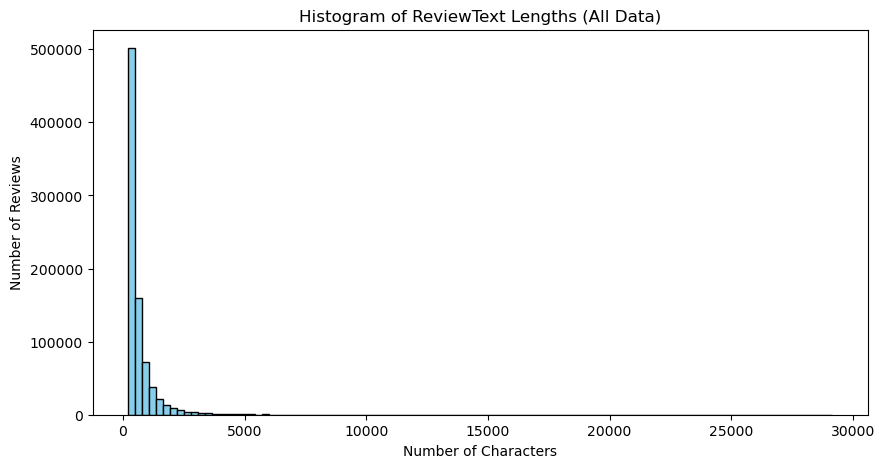

In [19]:
plt.figure(figsize=(10,5))
plt.hist(df['text_length'], bins=100, color='skyblue', edgecolor='black')
plt.title("Histogram of ReviewText Lengths (All Data)")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")
plt.show()

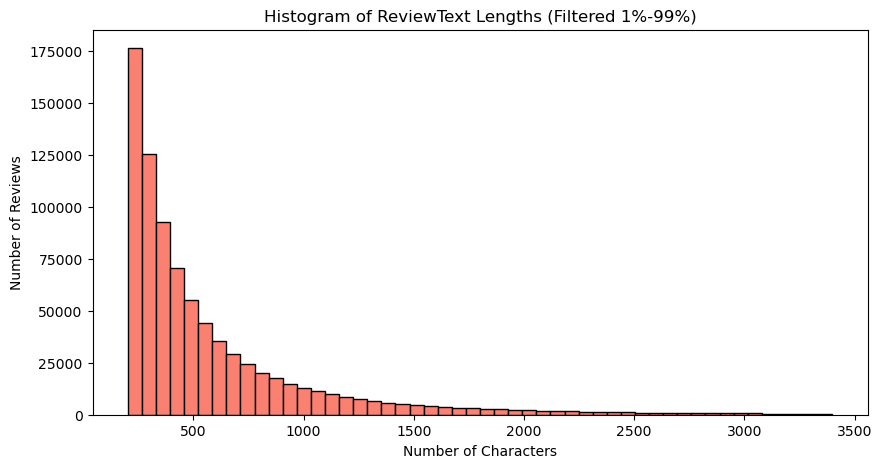

Filtered length range: 202 - 3399 characters


In [20]:
# تعیین بازه فیلتر شده (1 تا 99 درصد)
lower = df['text_length'].quantile(0.01)
upper = df['text_length'].quantile(0.99)

filtered_lengths = df[(df['text_length'] >= lower) & (df['text_length'] <= upper)]['text_length']

plt.figure(figsize=(10,5))
plt.hist(filtered_lengths, bins=50, color='salmon', edgecolor='black')
plt.title("Histogram of ReviewText Lengths (Filtered 1%-99%)")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")
plt.show()

print(f"Filtered length range: {lower:.0f} - {upper:.0f} characters")

<div dir = "rtl">

۱. تمرکز طول متن‌ها:
بیشترین تعداد نظرات در بازه‌ی ۲۰۰ تا ۳۰۰ کاراکتر قرار دارند (تقریباً ۱۷۶,۴۹۱ در اولین bin و ۱۲۵,۴۶۷ در دومین bin). به‌طور کلی، اکثر نظرات بین ۲۰۰ تا ۴۰۰ کاراکتر هستند، که نشان می‌دهد کاربران معمولاً متن متوسطی برای نظرات خود می‌نویسند.

۲. دم طولانی (Long Tail):
تعداد کمی از نظرات طولانی هستند و تا بیش از ۳,۳۰۰ کاراکتر نیز می‌رسند، اما تعداد آن‌ها بسیار کم است (کمتر از ۵۰۰ نظر در هر bin آخر). این بخش‌های طولانی به مدل‌های NLP فشار حافظه و زمان آموزش زیادی وارد می‌کنند.

کاهش نویز و فیلتر کردن:
برای آموزش مدل، نظرات خیلی کوتاه (<۲۰۰ کاراکتر) و خیلی طولانی (>۱,۰۰۰ کاراکتر) می‌توانند حذف یا کوتاه شوند، چون متن کوتاه کمکی به مدل نمی‌کند و متن خیلی طولانی باعث افزایش پیچیدگی می‌شود.

پیشنهاد محدوده مناسب برای مدل‌سازی:

طول حداقل: ۲۰۰ کاراکتر

طول حداکثر: ۱,۰۰۰ کاراکتر
این بازه بیش از ۹۰٪ داده‌ها را پوشش می‌دهد و مدل هم سریع‌تر و پایدارتر آموزش می‌بیند.

<div dir="rtl">
<strong> . کدام محصولات بیشترین امتیاز ۵ را کسب کرده‌اند؟ ۱۰ مورد برتر را به‌ترتیب به‌صورت یک جدول شامل نام برند، عنوان محصول و تعداد نظرات با امتیاز ۵ نمایش دهید.


In [21]:
title_brand = pd.read_csv("title_brand.csv")

In [22]:

# Filter only reviews with overall == 5
df_5 = df[df['overall'] == 5]

# Count number of 5-star reviews per product
top_products = df_5.groupby('asin').size().sort_values(ascending=False).head(10)

# Create a dataframe from the result
top_products_df = pd.DataFrame({
    'asin': top_products.index,
    'num_5star_reviews': top_products.values
})

# Merge with title_brand to get brand and title
top_products_df = top_products_df.merge(title_brand, on='asin', how='left')

# Reorder columns
top_products_df = top_products_df[['brand', 'title', 'num_5star_reviews']]

# Sort by number of 5-star reviews descending
top_products_df = top_products_df.sort_values(by='num_5star_reviews', ascending=False)

# Display the result
top_products_df

,brand,title,num_5star_reviews
0,Cambridge Soundworks,OontZ Angle 3 Enhanced Stereo Edition IPX5 Spl...,1163
1,NETGEAR,NETGEAR N300 WiFi Range Extender (EX2700),659
2,Roku,Roku Streaming Stick (3600R) - HD Streaming Pl...,600
3,StarTech,StarTech USB 2.0 to SATA IDE Adapter (USB2SATA...,598
4,Logitech,Logitech M570 Wireless Trackball Mouse &ndash;...,552
5,Samsung,Samsung 850 EVO 500GB 2.5-Inch SATA III Intern...,529
6,Asus,ASUS Tri-Band Gigabit (AC3200) WiFi Router (Up...,471
7,VideoSecu,VideoSecu ML531BE TV Wall Mount for Most 27&qu...,448
8,"Arlo Technologies, Inc",Arlo - Wireless Home Security Camera System | ...,433
9,Samsung,Samsung 850 EVO 250GB 2.5-Inch SATA III Intern...,431


<div dir="rtl">
<strong>. ابتدا ۱۰ برندی که بیشترین تعداد نظر را داشته‌اند پیدا کنید. سپس میانگین امتیاز هر کدام را محاسبه کرده و یک جدول شامل نام برند و میانگین امتیاز آن به‌ترتیب میانگین امتیاز نمایش دهید.


In [23]:
import pandas as pd

# Merge review data with brand info
df_brand = df.merge(title_brand[['asin','brand']], on='asin', how='left')

# Count number of reviews per brand
brand_counts = df_brand.groupby('brand').size()

# Take top 10 brands with most reviews
top10_brands = brand_counts.sort_values(ascending=False).head(10).index

# Filter dataframe to only top 10 brands
df_top10 = df_brand[df_brand['brand'].isin(top10_brands)]

# Calculate average overall score per brand
brand_avg = df_top10.groupby('brand')['overall'].mean()

# Convert to dataframe and sort by average descending
brand_avg_df = brand_avg.reset_index().sort_values(by='overall', ascending=False)
brand_avg_df.rename(columns={'overall':'average_score'}, inplace=True)


brand_avg_df

,brand,average_score
1,Anker,4.244320
0,AmazonBasics,4.201468
5,Sabrent,4.028005
7,SanDisk,3.958810
3,Logitech,3.954061
6,Samsung,3.941268
8,Sony,3.938726
9,TP-LINK,3.928681
2,Asus,3.855550
4,NETGEAR,3.836274


<h1 dir="rtl"> بخش ۲) میزان رضایت از یک جنبه‌ی مشخص

In [24]:
keywords = ["warranty", "guarantee"]

In [25]:
import spacy


In [26]:
# !python -m spacy download en_core_web_md

In [27]:

nlp = spacy.load("en_core_web_md")  # مدل متوسط با وکتورهای کلمات

similar_words = set(keywords)
for kw in keywords:
    kw_vector = nlp(kw)
    for token in nlp.vocab:
        if token.has_vector and token.is_lower and token.is_alpha:
            # شباهت کسینوسی
            if kw_vector.similarity(token) > 0.65:
                similar_words.add(token.text)

print(similar_words)

{'guarantee', 'warranty'}


In [ ]:
from rapidfuzz import fuzz

# main keywords + common variants
keywords = ["warranty", "guarantee", "warrantee", "guaranteed", "warrantees", "guarantees"]

# function to check if any keyword is present in text
def contains_warranty(text, keywords, threshold=80):
    words = text.lower().split()
    for w in words:
        for kw in keywords:
            if fuzz.ratio(w, kw.lower()) >= threshold:
                return True
    return False

# apply to dataframe
df['about_warranty'] = df['reviewText'].apply(lambda x: contains_warranty(x, keywords))

# filter only reviews about warranty
warranty_reviews = df[df['about_warranty']]

# calculate average overall score per product
warranty_avg = warranty_reviews.groupby('asin')['overall'].mean().reset_index()

# merge brand and title
warranty_avg = warranty_avg.merge(title_brand, on='asin', how='left')

# sort by average score descending
warranty_avg = warranty_avg.sort_values(by='overall', ascending=False)


In [ ]:

warranty_avg[['brand','title','overall']]

,brand,title,overall
0,SanDisk,Sandisk SDSDQUA-064G-A11 Professional Ultra 64...,5.0
2,SanDisk,SanDisk EXTREME PRO 64GB (95MB/s) MicroSDXC wo...,5.0
10925,RAVPower,RAVPower Type C Cable USB C to USB A 6ft Braid...,5.0
10924,Golden Spearhead,"100 Colorful Selected Stickers, No Adult Conte...",5.0
10923,HomeSpot,HomeSpot 5ft - 1.5m Long USB 2.0 to Micro USB ...,5.0
...,...,...,...
16,Seagate,Seagate ST3500320AS Barracuda 7200.11 500 GB S...,1.0
17,Seagate,Seagate ST3500320AS Barracuda 7200.11 500 GB S...,1.0
1,Canon,Canon EF 24-105mm f/4L IS USM Lens Bundle Inte...,1.0
8615,HP,HP Pavilion 23.8&quot; FHD IPS Touchscreen Aio...,1.0
